Este módulo describe el tratamiento avanzado de las variables geomorfológicas a partir del Modelo Digital de Elevación (DEM) Copernicus GLO-30.

El principal desafío metodológico de esta fase radicó en que el cálculo nativo de pendientes mediante ee.Terrain.slope() genera distorsiones severas si se ejecuta sobre el sistema de coordenadas geográficas original (EPSG:4326), debido a la severa deformación métrica horizontal ($dx, dy$) que experimentan los grados de longitud a latitudes extremas como la Patagonia chilena ($~53^{\circ}$ S). Para mitigar este sesgo y asegurar la honestidad matemática del modelo, se diseñó una rutina de reproyección espacial hacia el sistema métrico UTM (WGS 84 / UTM Zone 19S) previa al cálculo algorítmico, estabilizando la razón de cambio de la inclinación del terreno en grados reales.

El uso de suelo (CONAF) fue descargado por partes y descomprimido para luego ser unificado > inicialmente esta parte comprendía el uso de suelo de toda la región, pero debido a la falta de ram, el área de estudio se achicó, para recortar este raster a una zona especifica y optimizar el uso de los recursos.

Finalmente, para balancear la precisión territorial con las limitantes de hardware en la memoria volátil de Google Colab, las celdas (tiles) resultantes fueron remuestreadas a una resolución homogénea de 90 metros y consolidadas mediante un proceso de fusión matricial (merge) utilizando gdal_merge.py.

Variables programadas:
Pendiente / Viento / limite regional / uso de suelo

Existe un parte de limpieza de datos, de GEE y drive para eliminar archivos duplicados o dañados.






In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Verificar RAM disponible ANTES de hacer nada más
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       972Mi       8.5Gi       2.0Mi       3.3Gi        11Gi
Swap:             0B          0B          0B


In [ ]:
import subprocess

carpeta = '/content/drive/MyDrive/GEO3211_Eolico'

tiles = [
    f'{carpeta}/pendiente_grados_90m-0000000000-0000000000.tif',
    f'{carpeta}/pendiente_grados_90m-0000032768-0000000000.tif'
]

ruta_final = f'{carpeta}/pendiente_grados_90m_UNIFICADO.tif'

comando = ['gdal_merge.py', '-o', ruta_final, '-co', 'COMPRESS=LZW'] + tiles
resultado = subprocess.run(comando, capture_output=True, text=True)
print(resultado.stdout)
print(resultado.stderr)


Traceback (most recent call last):
  File "/usr/local/bin/gdal_merge.py", line 14, in <module>
    sys.exit(main(sys.argv))
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/osgeo_utils/gdal_merge.py", line 650, in main
    return gdal_merge(argv)
           ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/osgeo_utils/gdal_merge.py", line 525, in gdal_merge
    file_infos = names_to_fileinfos(names)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/osgeo_utils/gdal_merge.py", line 213, in names_to_fileinfos
    if fi.init_from_name(name) == 1:
       ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/osgeo_utils/gdal_merge.py", line 247, in init_from_name
    fh = gdal.Open(filename)
         ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py", line 5990, in Open
    return _gdal.Open(*args)
           ^^^^^^^^^^^^^^^^^
RuntimeError: /content/drive/MyD

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import subprocess

carpeta = '/content/drive/MyDrive/GEO3211_Eolico'

tiles = [
    f'{carpeta}/pendiente_grados_90m-0000000000-0000000000.tif',
    f'{carpeta}/pendiente_grados_90m-0000032768-0000000000.tif'
]

ruta_final = f'{carpeta}/pendiente_grados_90m_UNIFICADO.tif'

comando = ['gdal_merge.py', '-o', ruta_final, '-co', 'COMPRESS=LZW'] + tiles
resultado = subprocess.run(comando, capture_output=True, text=True)
print(resultado.stdout)
print(resultado.stderr)


Traceback (most recent call last):
  File "/usr/local/bin/gdal_merge.py", line 14, in <module>
    sys.exit(main(sys.argv))
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/osgeo_utils/gdal_merge.py", line 650, in main
    return gdal_merge(argv)
           ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/osgeo_utils/gdal_merge.py", line 525, in gdal_merge
    file_infos = names_to_fileinfos(names)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/osgeo_utils/gdal_merge.py", line 213, in names_to_fileinfos
    if fi.init_from_name(name) == 1:
       ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/osgeo_utils/gdal_merge.py", line 247, in init_from_name
    fh = gdal.Open(filename)
         ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py", line 5990, in Open
    return _gdal.Open(*args)
           ^^^^^^^^^^^^^^^^^
RuntimeError: /content/drive/MyD

In [ ]:
# Verificación inmediata
import rasterio
import numpy as np

with rasterio.open(ruta_final) as src:
    pendiente_arr = src.read(1)
    nodata_p = src.nodata
    crs_p = src.crs
    transform_p = src.transform

pendiente_arr = np.where(pendiente_arr == nodata_p, np.nan, pendiente_arr)

print(f"CRS: {crs_p}")
print(f"Resolución: {transform_p[0]:.1f} m")
print(f"Pendiente media: {np.nanmean(pendiente_arr):.2f}°")
print(f"Pendiente máxima: {np.nanmax(pendiente_arr):.2f}°")
print(f"Pendiente mínima: {np.nanmin(pendiente_arr):.2f}°")

CRS: EPSG:32719
Resolución: 90.0 m
Pendiente media: 13.02°
Pendiente máxima: 84.51°
Pendiente mínima: 0.00°


In [ ]:
# ============================================================
# PASO 1: Instalar las librerías necesarias (si no están ya)
# ============================================================
# En Colab normalmente ya vienen preinstaladas, pero por si acaso:
!pip install earthengine-api geemap --quiet --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 16.6 MB/s eta 0:00:00


In [ ]:
# ============================================================
# PASO 2: Importar y autenticar
# ============================================================
import ee
import geemap

# Esto abre un link de autorización (solo la primera vez por sesión/cuenta).
# Hay que iniciar sesión con la cuenta de Google que tiene acceso a GEE,
# copiar el código de verificación que entrega Google, y pegarlo donde pide.
ee.Authenticate()

In [ ]:
# ============================================================
# PASO 3: Inicializar con tu proyecto de Google Cloud
# ============================================================
# IMPORTANTE: deben reemplazar 'TU_PROYECTO_GEE' por el ID real
# de su proyecto, no por el nombre que le pusieron.

ee.Initialize(project='geoandres')

print("✅ Google Earth Engine inicializado correctamente")

✅ Google Earth Engine inicializado correctamente


In [ ]:
# ============================================================
# PASO 4: Prueba simple — debería devolver un número sin error
# ============================================================
prueba = ee.Number(1).add(1)
print("Si ves un 2 aquí, GEE está funcionando:", prueba.getInfo())

Si ves un 2 aquí, GEE está funcionando: 2


In [ ]:
# ============================================================
# Obtener el límite de Magallanes directo desde GEE (sin shapefile local)
# ============================================================
import ee
ee.Initialize(project='geoandres')

# FAO GAUL: divisiones administrativas globales (nivel 1 = regiones/provincias)
gaul = ee.FeatureCollection("FAO/GAUL/2015/level1")

magallanes_gee = gaul.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'Chile'),
        ee.Filter.stringContains('ADM1_NAME', 'Magallanes')
    )
)

print("Nombre encontrado:", magallanes_gee.first().get('ADM1_NAME').getInfo())

# Geometría lista para usar en recortes con GEE
geom_magallanes = magallanes_gee.geometry()

Nombre encontrado: Magallanes y Antartica chilena


In [ ]:
# Exportar la geometría de Magallanes como shapefile a Drive
task = ee.batch.Export.table.toDrive(
    collection=magallanes_gee,
    description='limite_magallanes',
    folder='GEO3211_Eolico',
    fileFormat='SHP'
)
task.start()
print("🚀 Exportando límite de Magallanes a Drive...")

🚀 Exportando límite de Magallanes a Drive...


In [ ]:
# ============================================================
# Monitorear el estado de la exportación del límite de Magallanes
# ============================================================
import time

while task.active():
    estado = task.status()['state']
    print(f"Estado actual: {estado}")
    time.sleep(15)   # consultamos cada 15 seg, esta tarea es liviana

print("Estado final:", task.status())

NameError: name 'task' is not defined

In [ ]:
# ============================================================
# Exportar Magallanes como GeoJSON (sin buffer, sin filtrado previo)
# ============================================================
import ee
ee.Initialize(project='geoandres')

gaul = ee.FeatureCollection("FAO/GAUL/2015/level1")

magallanes_gee = gaul.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'Chile'),
        ee.Filter.stringContains('ADM1_NAME', 'Magallanes')
    )
)

task = ee.batch.Export.table.toDrive(
    collection=magallanes_gee,
    description='limite_magallanes_geojson',
    folder='GEO3211_Eolico',
    fileFormat='GeoJSON'
)
task.start()
print("🚀 Exportando como GeoJSON...")

KeyboardInterrupt: 

In [ ]:
# ============================================================
# Monitorear (es liviano, debería terminar rápido)
# ============================================================
import time

while task.active():
    estado = task.status()['state']
    print(f"Estado actual: {estado}")
    time.sleep(15)

print("Estado final:", task.status())

NameError: name 'task' is not defined

In [ ]:
# ============================================================
# Simplificar la geometría antes de exportar (reduce vértices)
# ============================================================
import ee
ee.Initialize(project='geoandres')

gaul = ee.FeatureCollection("FAO/GAUL/2015/level1")

magallanes_gee = gaul.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'Chile'),
        ee.Filter.stringContains('ADM1_NAME', 'Magallanes')
    )
)

# simplify() reduce el número de vértices manteniendo la forma general
# maxError en metros: cuánto puede "desviarse" la geometría simplificada
geom_simplificada = magallanes_gee.geometry().simplify(maxError=500)

magallanes_simple = ee.FeatureCollection([ee.Feature(geom_simplificada)])

task = ee.batch.Export.table.toDrive(
    collection=magallanes_simple,
    description='limite_magallanes_simplificado',
    folder='GEO3211_Eolico',
    fileFormat='GeoJSON'
)
task.start()
print("🚀 Exportando geometría simplificada...")

🚀 Exportando geometría simplificada...


In [ ]:
# ============================================================
# Monitorear
# ============================================================
import time

while task.active():
    estado = task.status()['state']
    print(f"Estado actual: {estado}")
    time.sleep(15)

print("Estado final:", task.status())

NameError: name 'task' is not defined

Archivo encontrado: ['/content/drive/MyDrive/GEO3211_Eolico/limite_magallanes_simplificado.geojson']

Total de geometrías: 1
Tipos de geometría presentes: ['GeometryCollection']
CRS: EPSG:4326


<Axes: >

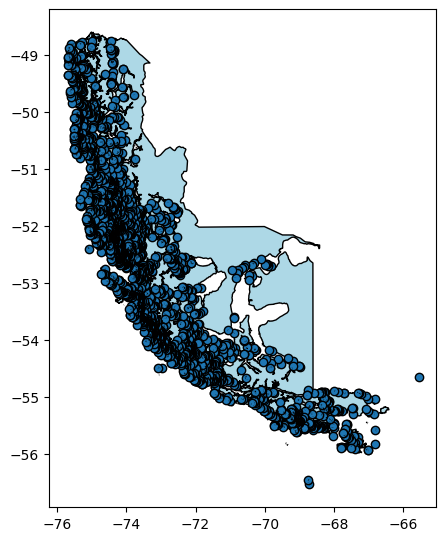

In [ ]:
# ============================================================
# Leer el GeoJSON simplificado de Magallanes
# ============================================================
import geopandas as gpd
import glob

carpeta = '/content/drive/MyDrive/GEO3211_Eolico'
archivo = glob.glob(f'{carpeta}/limite_magallanes_simplificado*.geojson')
print("Archivo encontrado:", archivo)

magallanes = gpd.read_file(archivo[0])
print(f"\nTotal de geometrías: {len(magallanes)}")
print("Tipos de geometría presentes:", magallanes.geometry.type.unique())
print("CRS:", magallanes.crs)

# Verificación visual
magallanes.plot(figsize=(5, 9), edgecolor='black', facecolor='lightblue')

Tipos de geometría ANTES de limpiar:
GeometryCollection    1
Name: count, dtype: int64

Tipos de geometría DESPUÉS de explotar:
LineString    4767
Polygon       2780
Point         2459
Name: count, dtype: int64

Geometrías finales (solo polígonos): 2780


<Axes: >

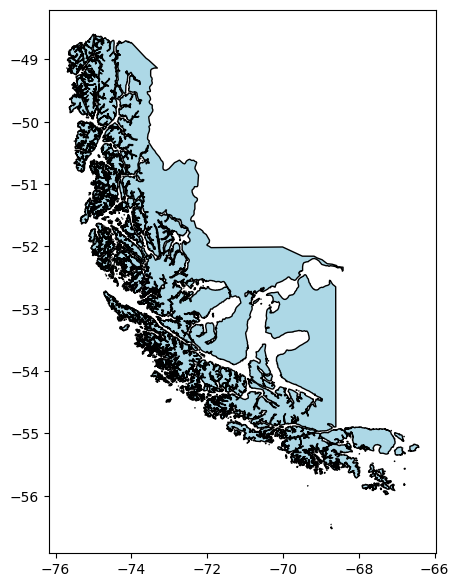

In [ ]:
# ============================================================
# LIMPIAR: descartar puntos sueltos, quedarse solo con polígonos
# ============================================================
import geopandas as gpd

carpeta = '/content/drive/MyDrive/GEO3211_Eolico'
archivo = '/content/drive/MyDrive/GEO3211_Eolico/limite_magallanes_simplificado.geojson'

magallanes_raw = gpd.read_file(archivo)

print("Tipos de geometría ANTES de limpiar:")
print(magallanes_raw.geometry.type.value_counts())

# Si la geometría es una sola fila con un GeometryCollection mixto,
# necesitamos "explotar" sus componentes para poder filtrar por tipo
magallanes_explotada = magallanes_raw.explode(index_parts=False)

print("\nTipos de geometría DESPUÉS de explotar:")
print(magallanes_explotada.geometry.type.value_counts())

# Quedarnos solo con polígonos (descarta Point, MultiPoint, LineString)
magallanes_limpia = magallanes_explotada[
    magallanes_explotada.geometry.type.isin(['Polygon', 'MultiPolygon'])
]

print(f"\nGeometrías finales (solo polígonos): {len(magallanes_limpia)}")

# Verificación visual
magallanes_limpia.plot(figsize=(5, 9), edgecolor='black', facecolor='lightblue')

✅ Shapefile final guardado: magallanes_limite_limpio.shp


<Axes: >

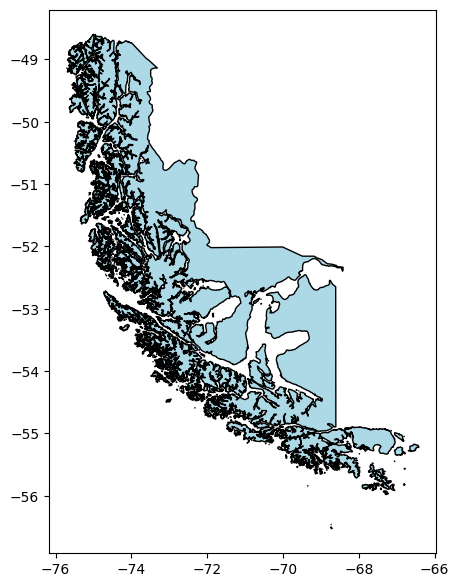

In [ ]:
# ============================================================
# Unir todos los polígonos/islas en una sola geometría (dissolve)
# y guardar el shapefile final limpio
# ============================================================
from shapely.ops import unary_union

geometria_unica = unary_union(magallanes_limpia.geometry)

magallanes_final = gpd.GeoDataFrame(
    {'region': ['Magallanes']},
    geometry=[geometria_unica],
    crs=magallanes_limpia.crs
)

magallanes_final.to_file(f'{carpeta}/magallanes_limite_limpio.shp')
print("✅ Shapefile final guardado: magallanes_limite_limpio.shp")

magallanes_final.plot(figsize=(5, 9), edgecolor='black', facecolor='lightblue')

In [ ]:
# ============================================================
# RECORTAR viento (EPSG:4326) a Magallanes — versión limpia
# ============================================================
import rasterio
from rasterio.mask import mask

magallanes_4326 = magallanes_final.to_crs('EPSG:4326')
geom_magallanes_4326 = [magallanes_4326.geometry.iloc[0].__geo_interface__]

with rasterio.open(f'{carpeta}/viento_medio_1996_2026.tif') as src:
    viento_recortado, transform_v = mask(src, geom_magallanes_4326, crop=True)
    perfil_v = src.profile.copy()
    perfil_v.update({
        'height': viento_recortado.shape[1],
        'width': viento_recortado.shape[2],
        'transform': transform_v
    })

with rasterio.open(f'{carpeta}/viento_magallanes.tif', 'w', **perfil_v) as dst:
    dst.write(viento_recortado)

print("✅ Viento recortado a Magallanes")

✅ Viento recortado a Magallanes


In [ ]:
# ============================================================
# RECORTAR pendiente (EPSG:32719) a Magallanes — versión limpia
# ============================================================
magallanes_utm = magallanes_final.to_crs('EPSG:32719')
geom_magallanes_utm = [magallanes_utm.geometry.iloc[0].__geo_interface__]

with rasterio.open(f'{carpeta}/pendiente_grados_90m_UNIFICADO.tif') as src:
    pendiente_recortada, transform_p = mask(src, geom_magallanes_utm, crop=True)
    perfil_p = src.profile.copy()
    perfil_p.update({
        'height': pendiente_recortada.shape[1],
        'width': pendiente_recortada.shape[2],
        'transform': transform_p
    })

with rasterio.open(f'{carpeta}/pendiente_magallanes.tif', 'w', **perfil_p) as dst:
    dst.write(pendiente_recortada)

print("✅ Pendiente recortada a Magallanes")

✅ Pendiente recortada a Magallanes


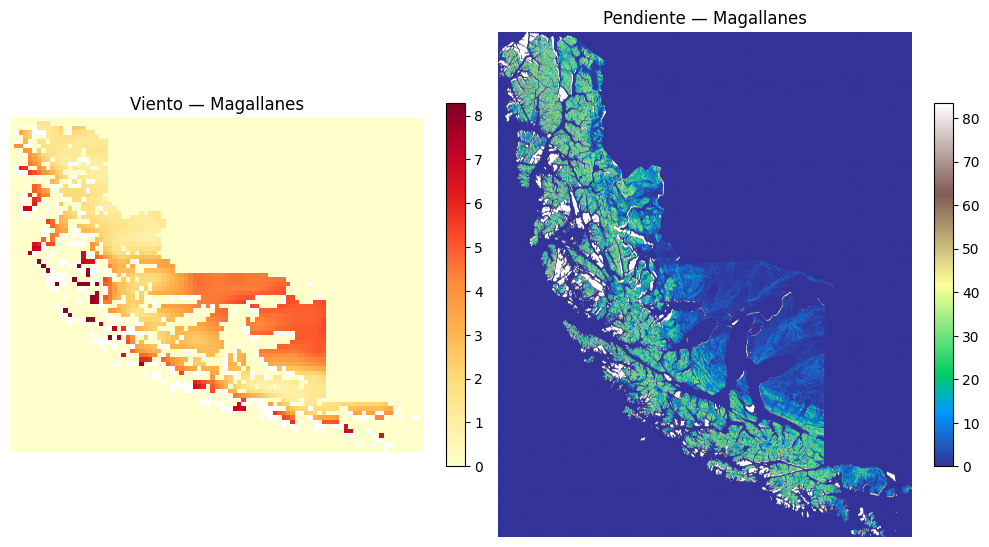

In [ ]:
# ============================================================
# Visualizar ambos recortes finales
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 8))

with rasterio.open(f'{carpeta}/viento_magallanes.tif') as src:
    v = src.read(1)
    v = np.where(v == src.nodata, np.nan, v)
im1 = axes[0].imshow(v, cmap='YlOrRd')
axes[0].set_title('Viento — Magallanes')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.04)

with rasterio.open(f'{carpeta}/pendiente_magallanes.tif') as src:
    p = src.read(1)
    p = np.where(p == src.nodata, np.nan, p)
im2 = axes[1].imshow(p, cmap='terrain')
axes[1].set_title('Pendiente — Magallanes')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], fraction=0.04)

plt.tight_layout()
plt.savefig(f'{carpeta}/recortes_magallanes.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# DIAGNÓSTICO: Estadísticas reales del viento recortado a Magallanes
# ============================================================
import rasterio
import numpy as np

carpeta = '/content/drive/MyDrive/GEO3211_Eolico'

with rasterio.open(f'{carpeta}/viento_magallanes.tif') as src:
    viento_mag = src.read(1)
    nodata = src.nodata
    print(f"Valor de NoData: {nodata}")

viento_mag_limpio = np.where(viento_mag == nodata, np.nan, viento_mag)

print(f"Velocidad media: {np.nanmean(viento_mag_limpio):.2f} m/s")
print(f"Velocidad máxima: {np.nanmax(viento_mag_limpio):.2f} m/s")
print(f"Velocidad mínima: {np.nanmin(viento_mag_limpio):.2f} m/s")
print(f"Percentil 25: {np.nanpercentile(viento_mag_limpio, 25):.2f} m/s")
print(f"Percentil 75: {np.nanpercentile(viento_mag_limpio, 75):.2f} m/s")

# Cuántos píxeles son NaN vs válidos
total = viento_mag.size
validos = np.sum(~np.isnan(viento_mag_limpio))
print(f"\nPíxeles válidos: {validos} de {total} ({100*validos/total:.1f}%)")

RasterioIOError: /content/drive/MyDrive/GEO3211_Eolico/viento_magallanes.tif: No such file or directory

In [ ]:
# ============================================================
# DIAGNÓSTICO: ¿de dónde vienen los ceros?
# ============================================================
import rasterio
import numpy as np

carpeta = '/content/drive/MyDrive/GEO3211_Eolico'

# Revisemos primero el archivo ORIGINAL (antes de recortar)
with rasterio.open(f'{carpeta}/viento_medio_1996_2026.tif') as src:
    viento_original = src.read(1)
    nodata_original = src.nodata
    print(f"NoData en archivo ORIGINAL: {nodata_original}")
    print(f"Mínimo en original: {np.nanmin(viento_original):.4f}")
    print(f"Cantidad de ceros exactos en original: {np.sum(viento_original == 0)}")

NoData en archivo ORIGINAL: None
Mínimo en original: 0.3329
Cantidad de ceros exactos en original: 0


In [ ]:
# ============================================================
# CORRECCIÓN: tratar los 0.00 exactos como NoData explícitamente
# ============================================================
with rasterio.open(f'{carpeta}/viento_magallanes.tif') as src:
    viento_mag = src.read(1)

# Enmascarar tanto el NoData formal (si existe) como los ceros exactos,
# que sabemos que son artefacto de recorte/relleno, no viento real
viento_mag_limpio = np.where(viento_mag <= 0.001, np.nan, viento_mag)

print(f"Velocidad media (corregida): {np.nanmean(viento_mag_limpio):.2f} m/s")
print(f"Velocidad máxima: {np.nanmax(viento_mag_limpio):.2f} m/s")
print(f"Velocidad mínima: {np.nanmin(viento_mag_limpio):.2f} m/s")
print(f"Percentil 25: {np.nanpercentile(viento_mag_limpio, 25):.2f} m/s")
print(f"Percentil 75: {np.nanpercentile(viento_mag_limpio, 75):.2f} m/s")

validos = np.sum(~np.isnan(viento_mag_limpio))
print(f"\nPíxeles válidos tras corrección: {validos} de {viento_mag.size}")

Velocidad media (corregida): 3.17 m/s
Velocidad máxima: 8.29 m/s
Velocidad mínima: 0.68 m/s
Percentil 25: 1.69 m/s
Percentil 75: 4.48 m/s

Píxeles válidos tras corrección: 1344 de 6975


In [ ]:
# ============================================================
# RE-RECORTAR viento, definiendo NoData explícito en el proceso
# ============================================================
import rasterio
from rasterio.mask import mask
import numpy as np

carpeta = '/content/drive/MyDrive/GEO3211_Eolico'

with rasterio.open(f'{carpeta}/viento_medio_1996_2026.tif') as src:
    # Forzamos un valor de nodata explícito (-9999, estándar en GIS)
    # que NO se confunda con valores reales de viento (siempre positivos)
    viento_recortado, transform_v = mask(
        src,
        geom_magallanes_4326,
        crop=True,
        nodata=-9999,        # clave: valor explícito de relleno
        filled=True
    )
    perfil_v = src.profile.copy()
    perfil_v.update({
        'height': viento_recortado.shape[1],
        'width': viento_recortado.shape[2],
        'transform': transform_v,
        'nodata': -9999      # clave: guardarlo también en los metadatos del archivo
    })

with rasterio.open(f'{carpeta}/viento_magallanes_v2.tif', 'w', **perfil_v) as dst:
    dst.write(viento_recortado)

print("✅ Viento re-recortado con NoData explícito (-9999)")

✅ Viento re-recortado con NoData explícito (-9999)


In [ ]:
# ============================================================
# VERIFICAR el nuevo archivo, ahora con NoData correctamente definido
# ============================================================
with rasterio.open(f'{carpeta}/viento_magallanes_v2.tif') as src:
    viento_v2 = src.read(1)
    nodata_v2 = src.nodata
    print(f"NoData definido: {nodata_v2}")

viento_v2_limpio = np.where(viento_v2 == nodata_v2, np.nan, viento_v2)

print(f"Velocidad media: {np.nanmean(viento_v2_limpio):.2f} m/s")
print(f"Velocidad máxima: {np.nanmax(viento_v2_limpio):.2f} m/s")
print(f"Velocidad mínima: {np.nanmin(viento_v2_limpio):.2f} m/s")
print(f"Percentil 25: {np.nanpercentile(viento_v2_limpio, 25):.2f} m/s")
print(f"Percentil 75: {np.nanpercentile(viento_v2_limpio, 75):.2f} m/s")

NoData definido: -9999.0
Velocidad media: 3.17 m/s
Velocidad máxima: 8.29 m/s
Velocidad mínima: 0.68 m/s
Percentil 25: 1.69 m/s
Percentil 75: 4.48 m/s


In [ ]:
# ============================================================
# Verificar NoData en pendiente recortada a Magallanes
# ============================================================
with rasterio.open(f'{carpeta}/pendiente_magallanes.tif') as src:
    pendiente_mag = src.read(1)
    nodata_pend = src.nodata
    print(f"NoData definido: {nodata_pend}")

pendiente_mag_limpio = np.where(pendiente_mag == nodata_pend, np.nan, pendiente_mag)

print(f"Pendiente media: {np.nanmean(pendiente_mag_limpio):.2f}°")
print(f"Pendiente máxima: {np.nanmax(pendiente_mag_limpio):.2f}°")
print(f"Pendiente mínima: {np.nanmin(pendiente_mag_limpio):.2f}°")


NoData definido: None
Pendiente media: 3.26°
Pendiente máxima: 83.52°
Pendiente mínima: 0.00°


In [ ]:
# ============================================================
# RE-RECORTAR pendiente, definiendo NoData explícito
# ============================================================
import rasterio
from rasterio.mask import mask
import numpy as np

carpeta = '/content/drive/MyDrive/GEO3211_Eolico'

# Asegúrate de tener geom_magallanes_utm definido (si reiniciaste,
# regenéralo con: magallanes_utm = magallanes_final.to_crs('EPSG:32719')
#                 geom_magallanes_utm = [magallanes_utm.geometry.iloc[0].__geo_interface__]

with rasterio.open(f'{carpeta}/pendiente_grados_90m_UNIFICADO.tif') as src:
    pendiente_recortada, transform_p = mask(
        src,
        geom_magallanes_utm,
        crop=True,
        nodata=-9999,
        filled=True
    )
    perfil_p = src.profile.copy()
    perfil_p.update({
        'height': pendiente_recortada.shape[1],
        'width': pendiente_recortada.shape[2],
        'transform': transform_p,
        'nodata': -9999
    })

with rasterio.open(f'{carpeta}/pendiente_magallanes_v2.tif', 'w', **perfil_p) as dst:
    dst.write(pendiente_recortada)

print("✅ Pendiente re-recortada con NoData explícito (-9999)")

✅ Pendiente re-recortada con NoData explícito (-9999)


In [ ]:
# ============================================================
# VERIFICAR el resultado corregido
# ============================================================
with rasterio.open(f'{carpeta}/pendiente_magallanes_v2.tif') as src:
    pendiente_v2 = src.read(1)
    nodata_pv2 = src.nodata
    print(f"NoData definido: {nodata_pv2}")

pendiente_v2_limpio = np.where(pendiente_v2 == nodata_pv2, np.nan, pendiente_v2)

print(f"Pendiente media: {np.nanmean(pendiente_v2_limpio):.2f}°")
print(f"Pendiente máxima: {np.nanmax(pendiente_v2_limpio):.2f}°")
print(f"Pendiente mínima: {np.nanmin(pendiente_v2_limpio):.2f}°")

NoData definido: -9999.0
Pendiente media: 14.55°
Pendiente máxima: 83.52°
Pendiente mínima: 0.00°


In [ ]:
# ============================================================
# AUDITORÍA: listar TODOS los archivos reales en la carpeta,
# con tamaño y fecha de modificación
# ============================================================
import os
from datetime import datetime

carpeta = '/content/drive/MyDrive/GEO3211_Eolico'

archivos_info = []
for nombre in os.listdir(carpeta):
    ruta = os.path.join(carpeta, nombre)
    if os.path.isfile(ruta):
        tamano_mb = os.path.getsize(ruta) / (1024*1024)
        mod_time = datetime.fromtimestamp(os.path.getmtime(ruta))
        archivos_info.append((nombre, tamano_mb, mod_time))

# Ordenar por nombre para verlos agrupados
archivos_info.sort(key=lambda x: x[0])

print(f"{'ARCHIVO':<55} {'TAMAÑO (MB)':>12}  {'MODIFICADO'}")
print("-" * 95)
for nombre, tamano, mod in archivos_info:
    print(f"{nombre:<55} {tamano:>10.1f}  {mod.strftime('%Y-%m-%d %H:%M')}")

print(f"\nTotal de archivos: {len(archivos_info)}")
print(f"Espacio total ocupado: {sum(a[1] for a in archivos_info):.1f} MB")

ARCHIVO                                                  TAMAÑO (MB)  MODIFICADO
-----------------------------------------------------------------------------------------------
limite_magallanes_simplificado.geojson                         2.7  2026-06-22 06:22
magallanes_limite_limpio.cpg                                   0.0  2026-06-22 06:24
magallanes_limite_limpio.dbf                                   0.0  2026-06-22 06:24
magallanes_limite_limpio.prj                                   0.0  2026-06-22 06:24
magallanes_limite_limpio.shp                                   0.8  2026-06-22 06:24
magallanes_limite_limpio.shx                                   0.0  2026-06-22 06:24
pendiente_grados-0000000000-0000000000.tif                   976.1  2026-06-20 01:33
pendiente_grados-0000032768-0000000000.tif                   763.5  2026-06-20 01:33
pendiente_grados-0000065536-0000000000.tif                   777.6  2026-06-20 01:33
pendiente_grados-0000098304-0000000000.tif                

In [ ]:
# ============================================================
# PASO 1: Listar lo que se va a borrar (sin borrar aún) — VERIFICACIÓN
# ============================================================
import os

carpeta = '/content/drive/MyDrive/GEO3211_Eolico'

archivos_a_borrar = [
    'pendiente_grados-0000000000-0000000000.tif',
    'pendiente_grados-0000032768-0000000000.tif',
    'pendiente_grados-0000065536-0000000000.tif',
    'pendiente_grados-0000098304-0000000000.tif',
    'pendiente_grados-0000131072-0000000000.tif',
    'pendiente_grados_90m-0000000000-0000000000 (1).tif',
    'pendiente_grados_90m-0000000000-0000000000 (2).tif',
    'pendiente_grados_90m-0000000000-0000000000 (3).tif',
    'pendiente_grados_90m-0000000000-0000000000.tif',
    'pendiente_grados_90m-0000032768-0000000000 (1).tif',
    'pendiente_grados_90m-0000032768-0000000000 (2).tif',
    'pendiente_grados_90m-0000032768-0000000000.tif',
    'pendiente_magallanes.tif',
    'viento_magallanes.tif',
    'viento_medio_1996_2026 (1).tif',
]

espacio_a_liberar = 0
print("Archivos que se eliminarán:\n")
for nombre in archivos_a_borrar:
    ruta = os.path.join(carpeta, nombre)
    if os.path.exists(ruta):
        tamano_mb = os.path.getsize(ruta) / (1024*1024)
        espacio_a_liberar += tamano_mb
        print(f"  ✓ {nombre} ({tamano_mb:.1f} MB)")
    else:
        print(f"  ⚠️ NO ENCONTRADO (revisar nombre): {nombre}")

print(f"\nEspacio total a liberar: {espacio_a_liberar:.1f} MB")

Archivos que se eliminarán:

  ✓ pendiente_grados-0000000000-0000000000.tif (976.1 MB)
  ✓ pendiente_grados-0000032768-0000000000.tif (763.5 MB)
  ✓ pendiente_grados-0000065536-0000000000.tif (777.6 MB)
  ✓ pendiente_grados-0000098304-0000000000.tif (766.4 MB)
  ✓ pendiente_grados-0000131072-0000000000.tif (242.5 MB)
  ✓ pendiente_grados_90m-0000000000-0000000000 (1).tif (283.4 MB)
  ✓ pendiente_grados_90m-0000000000-0000000000 (2).tif (283.4 MB)
  ✓ pendiente_grados_90m-0000000000-0000000000 (3).tif (283.4 MB)
  ✓ pendiente_grados_90m-0000000000-0000000000.tif (283.4 MB)
  ✓ pendiente_grados_90m-0000032768-0000000000 (1).tif (114.6 MB)
  ✓ pendiente_grados_90m-0000032768-0000000000 (2).tif (114.6 MB)
  ✓ pendiente_grados_90m-0000032768-0000000000.tif (114.6 MB)
  ✓ pendiente_magallanes.tif (61.5 MB)
  ✓ viento_magallanes.tif (0.0 MB)
  ✓ viento_medio_1996_2026 (1).tif (0.1 MB)

Espacio total a liberar: 5065.3 MB


In [ ]:
# ============================================================
# PASO 2: BORRAR — solo correr esto después de confirmar el Paso 1
# ============================================================
borrados = 0
for nombre in archivos_a_borrar:
    ruta = os.path.join(carpeta, nombre)
    if os.path.exists(ruta):
        os.remove(ruta)
        borrados += 1
        print(f"🗑️ Eliminado: {nombre}")

print(f"\n✅ {borrados} archivos eliminados")

🗑️ Eliminado: pendiente_grados-0000000000-0000000000.tif
🗑️ Eliminado: pendiente_grados-0000032768-0000000000.tif
🗑️ Eliminado: pendiente_grados-0000065536-0000000000.tif
🗑️ Eliminado: pendiente_grados-0000098304-0000000000.tif
🗑️ Eliminado: pendiente_grados-0000131072-0000000000.tif
🗑️ Eliminado: pendiente_grados_90m-0000000000-0000000000 (1).tif
🗑️ Eliminado: pendiente_grados_90m-0000000000-0000000000 (2).tif
🗑️ Eliminado: pendiente_grados_90m-0000000000-0000000000 (3).tif
🗑️ Eliminado: pendiente_grados_90m-0000000000-0000000000.tif
🗑️ Eliminado: pendiente_grados_90m-0000032768-0000000000 (1).tif
🗑️ Eliminado: pendiente_grados_90m-0000032768-0000000000 (2).tif
🗑️ Eliminado: pendiente_grados_90m-0000032768-0000000000.tif
🗑️ Eliminado: pendiente_magallanes.tif
🗑️ Eliminado: viento_magallanes.tif
🗑️ Eliminado: viento_medio_1996_2026 (1).tif

✅ 15 archivos eliminados


In [ ]:
# ============================================================
# PASO 3: Verificación final — listar lo que queda
# ============================================================
print("Archivos restantes en la carpeta:\n")
for nombre in sorted(os.listdir(carpeta)):
    ruta = os.path.join(carpeta, nombre)
    if os.path.isfile(ruta):
        tamano_mb = os.path.getsize(ruta) / (1024*1024)
        print(f"  {nombre} — {tamano_mb:.1f} MB")

Archivos restantes en la carpeta:

  limite_magallanes_simplificado.geojson — 2.7 MB
  magallanes_limite_limpio.cpg — 0.0 MB
  magallanes_limite_limpio.dbf — 0.0 MB
  magallanes_limite_limpio.prj — 0.0 MB
  magallanes_limite_limpio.shp — 0.8 MB
  magallanes_limite_limpio.shx — 0.0 MB
  pendiente_grados_90m_UNIFICADO.tif — 398.3 MB
  pendiente_magallanes_v2.tif — 63.0 MB
  recortes_magallanes.png — 0.8 MB
  viento_magallanes_v2.tif — 0.0 MB
  viento_medio_1996_2026.tif — 0.1 MB
  viento_medio_mapa.png — 0.1 MB


In [ ]:
# ============================================================
# PASO 1: Montar Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# PASO 2: Descomprimir las 4 zonas descargadas
# ============================================================
import zipfile
import os
import glob

carpeta_raw = '/content/drive/MyDrive/GEO3211_Eolico/uso_suelo_raw'

# Listar qué .zip hay realmente (para confirmar nombres exactos)
zips_encontrados = glob.glob(f'{carpeta_raw}/*.zip')
print("Archivos .zip encontrados:")
for z in zips_encontrados:
    print(f"  {z}")

Archivos .zip encontrados:


In [1]:
# ============================================================
# DIAGNÓSTICO: Ver TODO lo que hay en la carpeta, sin filtrar por extensión
# ============================================================
import os

carpeta_raw = '/content/drive/MyDrive/GEO3211_Eolico/uso_suelo_raw '

if os.path.exists(carpeta_raw):
    print(f"📁 Contenido completo de {carpeta_raw}:\n")
    for nombre in os.listdir(carpeta_raw):
        ruta_completa = os.path.join(carpeta_raw, nombre)
        if os.path.isfile(ruta_completa):
            tamano_mb = os.path.getsize(ruta_completa) / (1024*1024)
            print(f"  📄 {nombre}  —  {tamano_mb:.1f} MB")
        else:
            print(f"  📁 {nombre}  (carpeta)")
else:
    print(f"⚠️ La carpeta no existe en absoluto: {carpeta_raw}")
    print("\nRevisando si 'uso_suelo_raw' existe con otro nombre/mayúsculas...")
    carpeta_padre = '/content/drive/MyDrive/GEO3211_Eolico'
    print(os.listdir(carpeta_padre))

⚠️ La carpeta no existe en absoluto: /content/drive/MyDrive/GEO3211_Eolico/uso_suelo_raw 

Revisando si 'uso_suelo_raw' existe con otro nombre/mayúsculas...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/GEO3211_Eolico'

In [ ]:
# Forzar remount de Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# ============================================================
# Verificar de nuevo, mostrando TODO sin filtrar
# ============================================================
import os

carpeta_raw = '/content/drive/MyDrive/GEO3211_Eolico/uso_suelo_raw '
print(os.listdir(carpeta_raw))

['12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_2_este.zip', '12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_1.zip', '12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_2_oeste.zip', '12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_3.zip']


In [ ]:
# ============================================================
# Listar los 4 zips con sus nombres completos (sin truncar)
# ============================================================
import glob

carpeta_raw = '/content/drive/MyDrive/GEO3211_Eolico/uso_suelo_raw '

zips_encontrados = glob.glob(f'{carpeta_raw}/*.zip')
print(f"Total encontrados: {len(zips_encontrados)}\n")
for z in zips_encontrados:
    print(f"  {z}")

Total encontrados: 4

  /content/drive/MyDrive/GEO3211_Eolico/uso_suelo_raw /12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_2_este.zip
  /content/drive/MyDrive/GEO3211_Eolico/uso_suelo_raw /12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_1.zip
  /content/drive/MyDrive/GEO3211_Eolico/uso_suelo_raw /12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_2_oeste.zip
  /content/drive/MyDrive/GEO3211_Eolico/uso_suelo_raw /12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_3.zip


In [ ]:
# ============================================================
# Descomprimir cada zona en su propia subcarpeta
# ============================================================
import zipfile
import os

for zip_path in zips_encontrados:
    nombre_base = os.path.splitext(os.path.basename(zip_path))[0]
    carpeta_destino = f'{carpeta_raw}/{nombre_base}'
    os.makedirs(carpeta_destino, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(carpeta_destino)

    print(f"✅ Descomprimido: {nombre_base}")

✅ Descomprimido: 12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_2_este
✅ Descomprimido: 12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_1
✅ Descomprimido: 12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_2_oeste
✅ Descomprimido: 12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_3


In [ ]:
# ============================================================
# Buscar los .shp dentro de las carpetas descomprimidas
# ============================================================
shapefiles = glob.glob(f'{carpeta_raw}/**/*.shp', recursive=True)
print(f"Shapefiles encontrados ({len(shapefiles)}):")
for s in shapefiles:
    print(f"  {s}")

Shapefiles encontrados (4):
  /content/drive/MyDrive/GEO3211_Eolico/uso_suelo_raw /12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_2_este/12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_2_este.shp
  /content/drive/MyDrive/GEO3211_Eolico/uso_suelo_raw /12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_1/12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_1.shp
  /content/drive/MyDrive/GEO3211_Eolico/uso_suelo_raw /12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_2_oeste/12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_2_oeste.shp
  /content/drive/MyDrive/GEO3211_Eolico/uso_suelo_raw /12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_3/12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_3.shp


In [ ]:
# ============================================================
# Revisar estructura de cada una de las 4 zonas
# ============================================================
import geopandas as gpd

gdfs = []
for shp in shapefiles:
    gdf = gpd.read_file(shp)
    nombre_zona = shp.split('/')[-1]
    print(f"\n{'='*60}")
    print(f"📄 {nombre_zona}")
    print(f"{'='*60}")
    print(f"   Filas (polígonos): {len(gdf)}")
    print(f"   CRS: {gdf.crs}")
    print(f"   Columnas: {gdf.columns.tolist()}")
    gdfs.append(gdf)


📄 12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_2_este.shp
   Filas (polígonos): 65920
   CRS: EPSG:32719
   Columnas: ['ID', 'OBJECTID', 'ORG_ESP_CC', 'ID_USO', 'ID_SUBUSO', 'ID_ESTRUC', 'ID_COBER', 'ID_ALTU', 'ID_TIFO', 'ID_STIF', 'ID_ESP1', 'ID_ESP2', 'ID_ESP3', 'ID_ESP4', 'ID_ESP5', 'ID_ESP6', 'ID_ESP_CC1', 'ID_ESP_CC2', 'CODCOM', 'CODPROV', 'CODREG', 'USO_TIERRA', 'USO', 'SUBUSO', 'ESTRUCTURA', 'ALTURA', 'COBERTURA', 'TIPO_FORES', 'SUBTIPOFOR', 'ESPECI1_CI', 'ESPECI2_CI', 'ESPECI3_CI', 'ESPECI4_CI', 'ESPECI5_CI', 'ESPECI6_CI', 'ESPECI1_CO', 'ESPECI2_CO', 'ESPECI3_CO', 'ESPECI4_CO', 'ESPECI5_CO', 'ESPECI6_CO', 'ESP_C1', 'ESP_C2', 'COOR_ESTE', 'SUPERF_HA', 'COOR_NORTE', 'NOM_SNASPE', 'TIPO_SNASP', 'NOM_REG', 'NOM_PROV', 'NOM_COM', 'TC', 'TIPO_POLI', 'geometry']

📄 12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_1.shp
   Filas (polígonos): 64606
   CRS: EPSG:32719
   Columnas: ['ID', 'ID_USO', 'ID_SUBUSO', 'ID_ESTRUC', 'ID_COBER', 'ID_ALTU', 'ID_TIFO', 'ID_STIF', 'ID_ESP

In [ ]:
# ============================================================
# Ver las categorías de USO en cada zona (antes de unificar)
# ============================================================
for gdf, shp in zip(gdfs, shapefiles):
    nombre_zona = shp.split('/')[-1]
    print(f"\n📄 {nombre_zona}")
    print(gdf['USO'].value_counts())


📄 12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_2_este.shp
USO
Bosques                             30768
Praderas y Matorrales               23263
Cuerpos de Agua                      6093
Humedales                            3893
Áreas Desprovistas de Vegetación     1472
Terrenos Agrícolas                    200
Áreas Urbanas e Industriales          135
Nieves Eternas y Glaciares             91
Áreas no Reconocidas                    5
Name: count, dtype: int64

📄 12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_1.shp
USO
Praderas y Matorrales                 26928
Bosques                               23243
Humedales                              5841
Cuerpos de Agua                        4324
Ãreas Desprovistas de VegetaciÃ³n     1892
Terrenos AgrÃ­colas                     807
Ãreas Urbanas e Industriales           797
Nieves Eternas y Glaciares              774
Name: count, dtype: int64

📄 12_regi_n_de_magallanes_actualizaci_n_2017_2019_zona_2_oeste.shp
USO
Bosques  

In [ ]:
# ============================================================
# CORRECCIÓN: Releer Zona 1 con encoding cp1252
# ============================================================
import geopandas as gpd

shp_zona1 = [s for s in shapefiles if 'zona_1' in s][0]
print(f"Releyendo: {shp_zona1}")

gdf_zona1_fix = gpd.read_file(shp_zona1, encoding='cp1252')

print("\nCategorías USO con encoding cp1252:")
print(gdf_zona1_fix['USO'].value_counts())

NameError: name 'shapefiles' is not defined